# 📊 Credit Risk & Customer Financial Health Analytics
### 🏢 FinTrust Digital Finance | Capstone Project
**Module:** ITS 2122 — Python for Data Science & AI  
**Intake:** HDSE 74

---

## 🛠️ Phase 1: Data Sanitation and Preprocessing
The objective of this phase is to load the raw financial portfolio dataset, audit its structure, handle anomalies, map categorical codes to readable labels, and engineer behavioral risk features.

In [1]:
import pandas as pd

/home/savindu/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/savindu/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### 🔍 Step 1 - Initial Data Assessment & Audit Findings
Based on the execution of data info and description, we observe the following:
* **Dataset Dimensions:** The data contains exactly 30,000 customer records and 25 attributes.
* **Data Type Realignment:** By passing `header=1` during ingestion, the structural shifted rows were resolved. All columns are now numeric (`int64`).
* **Missing Values:** No explicitly missing (`NaN`) values are detected across the rows.

In [3]:
df = pd.read_csv('default of credit card clients.csv', header=1) 
print("--- Data Loaded Successfully! ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
# print(df)

--- Data Loaded Successfully! ---
Dataset Dimensions: 30000 rows, 25 columns



### Step 2 - Initial Assessment

Display the data types and column structural summary

In [4]:
print("--- Dataset Information ---")
print(df.info())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  

In [5]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [6]:
print(df.describe())

                 ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_1         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -0.220667   
std        9.217904      1.123802

### 🏷️ Step 3 & 4: Column Renaming & Categorical Decoding
To ensure readability, columns will be transformed into standard Python `snake_case`. 

Demographic features (`SEX`, `EDUCATION`, `MARRIAGE`) will be mapped to clean text labels. Undocumented codes (0, 5, 6) in education and marriage will be safely handled as 'Unknown' to maintain data integrity.

In [7]:

rename_dict = {
    'LIMIT_BAL': 'limit_balance',
    'SEX': 'gender',
    'EDUCATION': 'education',
    'MARRIAGE': 'marital_status',
    'AGE': 'age',
    'PAY_1': 'pay_status_1', 'PAY_2': 'pay_status_2', 'PAY_3': 'pay_status_3',
    'PAY_4': 'pay_status_4', 'PAY_5': 'pay_status_5', 'PAY_6': 'pay_status_6',
    'BILL_AMT1': 'bill_amt_1', 'BILL_AMT2': 'bill_amt_2', 'BILL_AMT3': 'bill_amt_3',
    'BILL_AMT4': 'bill_amt_4', 'BILL_AMT5': 'bill_amt_5', 'BILL_AMT6': 'bill_amt_6',
    'PAY_AMT1': 'pay_amt_1', 'PAY_AMT2': 'pay_amt_2', 'PAY_AMT3': 'pay_amt_3',
    'PAY_AMT4': 'pay_amt_4', 'PAY_AMT5': 'pay_amt_5', 'PAY_AMT6': 'pay_amt_6',
    'default payment next month': 'default_next_month'
}
df.rename(columns=rename_dict, inplace=True)

gender_map = {1: 'Male', 2: 'Female'}
education_map = {1: 'Graduate School', 2: 'University', 3: 'High School', 4: 'Others', 0: 'Unknown', 5: 'Unknown', 6: 'Unknown'}
marriage_map = {1: 'Married', 2: 'Single', 3: 'Others', 0: 'Unknown'}

df['gender'] = df['gender'].map(gender_map)
df['education'] = df['education'].map(education_map)
df['marital_status'] = df['marital_status'].map(marriage_map)

print("--- Columns Renamed & Decoded Successfully! ---")
print(df[['gender', 'education', 'marital_status']].head())

--- Columns Renamed & Decoded Successfully! ---
   gender   education marital_status
0  Female  University        Married
1  Female  University         Single
2  Female  University         Single
3  Female  University        Married
4    Male  University        Married


### ⚙️ Step 5 & 6: Handling Duplicates & Basic Feature Engineering

In [8]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("--- Duplicate rows dropped successfully! ---")

age_bins = [20, 30, 45, 60, 80]
age_labels = ['Young Adult (21-30)', 'Middle-Aged (31-45)', 'Senior-Aged (46-60)', 'Elderly (61-80)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

bill_cols = ['bill_amt_1', 'bill_amt_2', 'bill_amt_3', 'bill_amt_4', 'bill_amt_5', 'bill_amt_6']
df['total_bill_amount'] = df[bill_cols].sum(axis=1)

print("\n--- Feature Engineering Completed! ---")
print(df[['age', 'age_group', 'total_bill_amount']].head())

Number of duplicate rows found: 0

--- Feature Engineering Completed! ---
   age            age_group  total_bill_amount
0   24  Young Adult (21-30)               7704
1   26  Young Adult (21-30)              17077
2   34  Middle-Aged (31-45)             101653
3   37  Middle-Aged (31-45)             231334
4   57  Senior-Aged (46-60)             109339


### ⚙️ Step 6: Advanced Behavioral Feature Engineering & Clean Data Export

To satisfy project requirements, we engineer specific risk metrics:
1. **`avg_bill_amt`**: Average bill amount over 6 months.
2. **`pay_to_bill_ratio`**: Ratio of average payment to average bill amount (indicates repayment capability).
3. **`delayed_months_count`**: Total count of months where payment was delayed (`pay_status` > 0).

Finally, the cleaned and enriched dataset is exported as `cleaned_credit_risk_data.csv`.

In [9]:
df['avg_bill_amt'] = df[['bill_amt_1', 'bill_amt_2', 'bill_amt_3', 'bill_amt_4', 'bill_amt_5', 'bill_amt_6']].mean(axis=1)

df['avg_pay_amt'] = df[['pay_amt_1', 'pay_amt_2', 'pay_amt_3', 'pay_amt_4', 'pay_amt_5', 'pay_amt_6']].mean(axis=1)

df['pay_to_bill_ratio'] = df['avg_pay_amt'] / (df['avg_bill_amt'] + 1)
df['pay_to_bill_ratio'] = df['pay_to_bill_ratio'].apply(lambda x: max(0, x)) # Negative values 0 කිරීම

pay_status_cols = ['pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6']
df['delayed_months_count'] = (df[pay_status_cols] > 0).sum(axis=1)

df.to_csv('cleaned_credit_risk_data.csv', index=False)

print("--- Behavioral Features Created & Cleaned Dataset Exported Successfully! ---")
print(df[['avg_bill_amt', 'avg_pay_amt', 'pay_to_bill_ratio', 'delayed_months_count']].head())

--- Behavioral Features Created & Cleaned Dataset Exported Successfully! ---
   avg_bill_amt  avg_pay_amt  pay_to_bill_ratio  delayed_months_count
0   1284.000000   114.833333           0.089364                     2
1   2846.166667   833.333333           0.292689                     2
2  16942.166667  1836.333333           0.108382                     0
3  38555.666667  1398.000000           0.036258                     0
4  18223.166667  9841.500000           0.540025                     0


## 📈 Phase 2: Exploratory Data Analysis (EDA)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
print("--- Visualization Libraries Loaded Successfully! ---")

--- Visualization Libraries Loaded Successfully! ---


### 📊 Step 1: Distribution of Default Payment Next Month
The primary objective here is to inspect the balance of our target variable (default_next_month). Understanding the class distribution is crucial as a severe imbalance will heavily impact our machine learning model's predictive performance.

In [12]:
# Default වෙන සහ නොවෙන අයගේ ගණන සෙවීම
default_counts = df['default_next_month'].value_counts()
default_percentages = df['default_next_month'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(f"Non-Defaulters (0): {default_counts[0]} ({default_percentages[0]:.2f}%)")
print(f"Defaulters (1): {default_counts[1]} ({default_percentages[1]:.2f}%)\n")

plt.figure(figsize=(6, 5))
ax = sns.countplot(x='default_next_month', hue='default_next_month', data=df, palette='Set2', legend=False)
plt.title('Distribution of Target Variable (Default Next Month)', fontsize=14, pad=15)
plt.xlabel('Default Status (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks([0, 1], ['Non-Defaulter (0)', 'Defaulter (1)'])

for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(df):.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 100
    ax.annotate(percentage, (x_pos, y_pos), ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

--- Class Distribution ---
Non-Defaulters (0): 23364 (77.88%)
Defaulters (1): 6636 (22.12%)



AttributeError: 'RcParams' object has no attribute '_get'

### 📊 Step 2: Demographic Analysis vs Default Risk
In this step, we analyze how customer demographics such as Gender and Education Level correlate with the default rates. This helps FinTrust Digital Finance understand which customer segments carry higher financial risk.

In [1]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='gender', hue='default_next_month', data=df, palette='pastel')
plt.title('Default Propensity by Gender', fontsize=13, pad=10)
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.legend(title='Default Status', labels=['Non-Defaulter (0)', 'Defaulter (1)'])

plt.subplot(1, 2, 2)
sns.countplot(x='education', hue='default_next_month', data=df, palette='pastel')
plt.title('Default Propensity by Education Level', fontsize=13, pad=10)
plt.xlabel('Education Level', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=20, ha='right') 
plt.legend(title='Default Status', labels=['Non-Defaulter (0)', 'Defaulter (1)'])

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### 📊 Step 3: Correlation Matrix and Insights
To understand the linear relationships between numeric financial metrics (such as credit limits, bill amounts, and repayment amounts) and the target risk variable, we construct a Correlation Heatmap. This helps identify structural patterns and multi-collinearity issues prior to training our predictive models.

In [2]:
correlation_cols = [
    'limit_balance', 'age', 'total_bill_amount', 
    'pay_amt_1', 'pay_amt_2', 'pay_amt_3', 
    'pay_status_1', 'pay_status_2', 'default_next_month'
]

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Financial & Risk Variables', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### 📊 Step 4: Additional Visualizations (Credit Limit, Age Bands, Repayment Trends)

/var/folders/vl/0spv1l4x0cv9f7y_kylhxgpr0000gn/T/ipykernel_26265/736383137.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Non-Defaulter (0)', 'Defaulter (1)'])


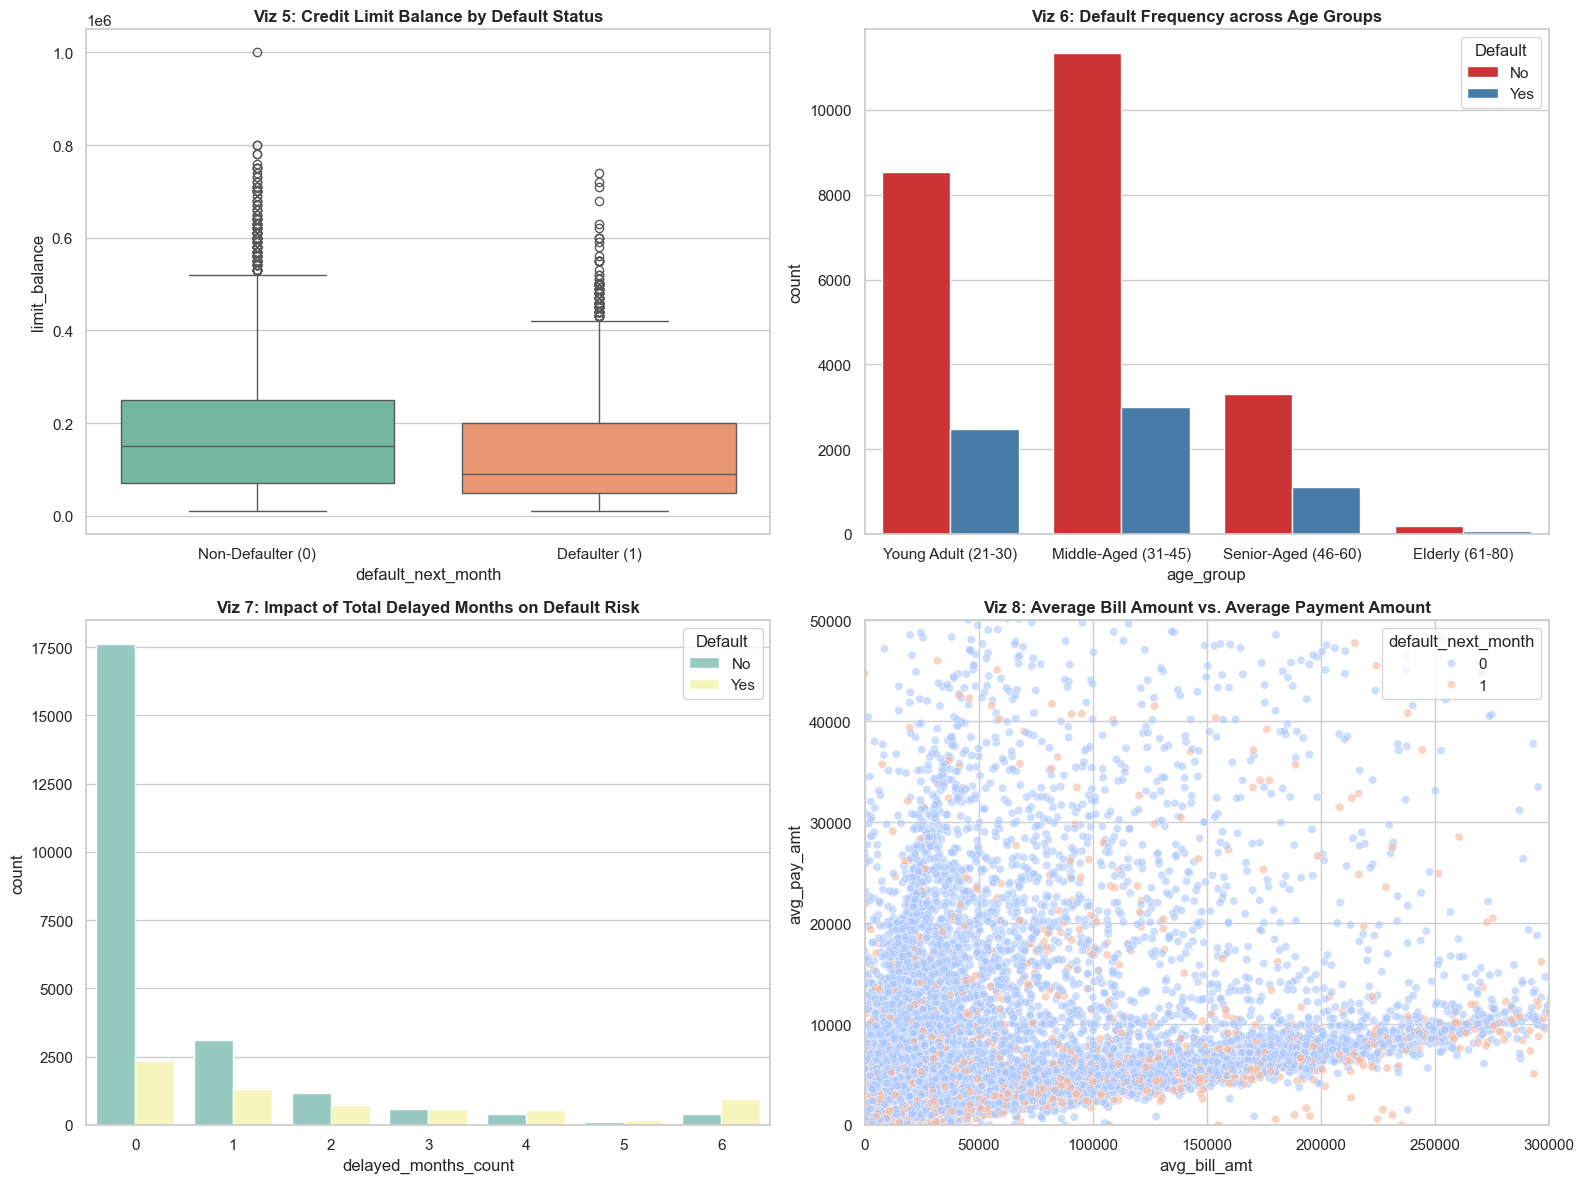

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(ax=axes[0, 0], x='default_next_month', y='limit_balance', data=df, palette='Set2', hue='default_next_month', legend=False)
axes[0, 0].set_title('Viz 5: Credit Limit Balance by Default Status', fontsize=12, weight='bold')
axes[0, 0].set_xticklabels(['Non-Defaulter (0)', 'Defaulter (1)'])

sns.countplot(ax=axes[0, 1], x='age_group', hue='default_next_month', data=df, palette='Set1')
axes[0, 1].set_title('Viz 6: Default Frequency across Age Groups', fontsize=12, weight='bold')
axes[0, 1].legend(title='Default', labels=['No', 'Yes'])

sns.countplot(ax=axes[1, 0], x='delayed_months_count', hue='default_next_month', data=df, palette='Set3')
axes[1, 0].set_title('Viz 7: Impact of Total Delayed Months on Default Risk', fontsize=12, weight='bold')
axes[1, 0].legend(title='Default', labels=['No', 'Yes'])

sns.scatterplot(ax=axes[1, 1], x='avg_bill_amt', y='avg_pay_amt', hue='default_next_month', data=df, alpha=0.6, palette='coolwarm')
axes[1, 1].set_title('Viz 8: Average Bill Amount vs. Average Payment Amount', fontsize=12, weight='bold')
axes[1, 1].set_xlim(0, 300000) 
axes[1, 1].set_ylim(0, 50000)

plt.tight_layout()
plt.show()

## 🎯 Phase 3: Advanced Analytics - Credit-Risk Segmentation

In this phase, we group customers into distinct **Financial Health Segments** based on their repayment behaviors, payment ratios, and historical delay patterns. This enables FinTrust Digital Finance to implement targeted intervention strategies.

### Segments Defined:
* 🟢 **Healthy**: Zero payment delays (`delayed_months_count` == 0)
* 🟡 **Watchlist**: Slight delays (1 to 2 delayed months)
* 🟠 **At-Risk**: Moderate-to-high delays (3 to 4 delayed months)
* 🔴 **Critical / Intervention**: Severe delays (5 or more delayed months)

In [ ]:
def assign_risk_segment(row):
    delays = row['delayed_months_count']
    
    if delays == 0:
        return 'Healthy'
    elif delays in [1, 2]:
        return 'Watchlist'
    elif delays in [3, 4]:
        return 'At-Risk'
    else:
        return 'Critical / Intervention'

df['risk_segment'] = df.apply(assign_risk_segment, axis=1)

segment_summary = df.groupby('risk_segment').agg(
    total_customers=('ID', 'count'),
    default_count=('default_next_month', 'sum'),
    default_rate=('default_next_month', 'mean'),
    avg_limit=('limit_balance', 'mean')
).reset_index()

segment_summary['default_rate'] = segment_summary['default_rate'] * 100

print("--- Credit Risk Segmentation Summary ---")
print(segment_summary.to_string(index=False))

--- Credit Risk Segmentation Summary ---
           risk_segment  total_customers  default_count  default_rate     avg_limit
                At-Risk             2105           1132     53.776722  97140.142518
Critical / Intervention             1639           1114     67.968273  93935.326419
                Healthy            19931           2334     11.710401 187259.429030
              Watchlist             6325           2056     32.505929 147639.841897


/var/folders/vl/0spv1l4x0cv9f7y_kylhxgpr0000gn/T/ipykernel_26265/35635013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_segment', data=df, order=segment_order, palette='Set2')
/var/folders/vl/0spv1l4x0cv9f7y_kylhxgpr0000gn/T/ipykernel_26265/35635013.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='default_rate', y='risk_segment', data=segment_summary, order=segment_order, palette='Reds_r')


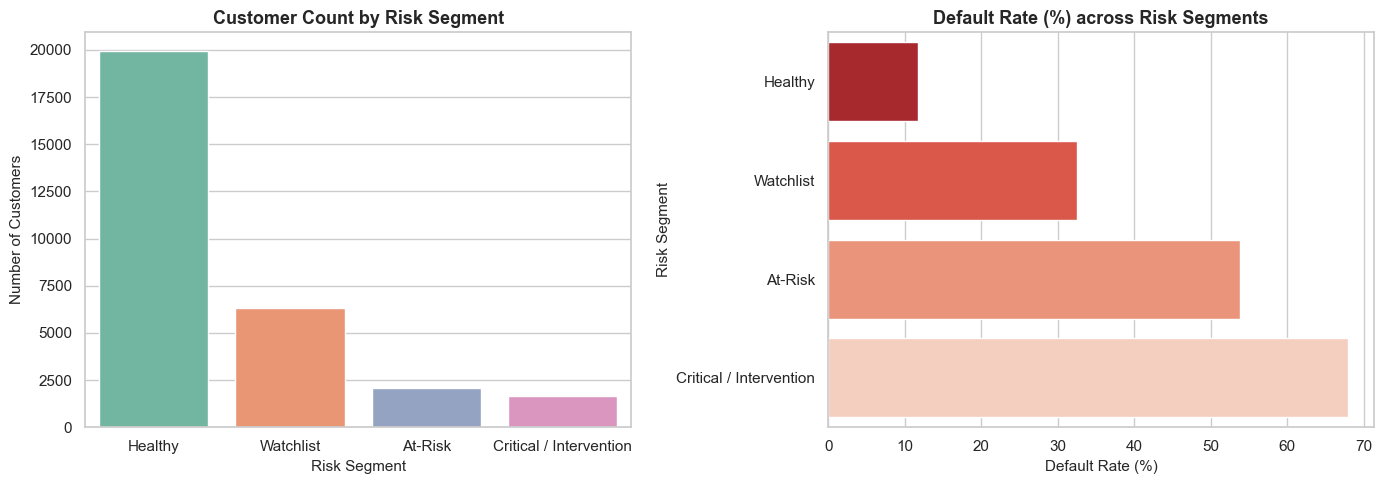

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
segment_order = ['Healthy', 'Watchlist', 'At-Risk', 'Critical / Intervention']
sns.countplot(x='risk_segment', data=df, order=segment_order, palette='Set2')
plt.title('Customer Count by Risk Segment', fontsize=13, weight='bold')
plt.xlabel('Risk Segment', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)

plt.subplot(1, 2, 2)
sns.barplot(x='default_rate', y='risk_segment', data=segment_summary, order=segment_order, palette='Reds_r')
plt.title('Default Rate (%) across Risk Segments', fontsize=13, weight='bold')
plt.xlabel('Default Rate (%)', fontsize=11)
plt.ylabel('Risk Segment', fontsize=11)

plt.tight_layout()
plt.show()

## External Data Acquisition & Enrichment via Currency API

### Project Dependencies & Imports
In this phase, we fetch external live foreign exchange (FX) rates using the `requests` library to convert our financial exposure metrics from **TWD** to **USD**. We also use `python-dotenv` to securely load API credentials without hardcoding them into the notebook.


In [ ]:
# %pip install -q requests python-dotenv pandas
import json
import os
import pandas as pd
import requests
from dotenv import load_dotenv



# Load Environment Variables from .env file
load_dotenv()

API_KEY = os.getenv("FASTFOREX_API_KEY")

FALLBACK_RATE = 0.031  
# Default static rate if API fails (1 TWD = 0.031 USD)

###  Live Exchange Rate Acquisition (API Fetching with Fail-Safe Handling)
We attempt to fetch the live conversion rate from **FastForex API**. If the API key is missing or an error occurs, the code automatically falls back to a **secondary public endpoint (Open Exchange Rates)** or a **predefined static fallback rate**, ensuring code resilience.

###  Primary API Acquisition (FastForex)

In this step, the system attempts to fetch the live foreign exchange rate (`TWD` to `USD`) using the primary **FastForex API**.

####  Execution Strategy:
* **API Key Authentication:** Retrieves the private API key securely from environment variables (`.env`).
* **Request Handling:** Sends an HTTP GET request to FastForex endpoint using the `requests` library with a 10-second timeout.
* **JSON Verification:** Parses the incoming JSON payload, prints a formatted sample for validation, and extracts the `USD` conversion rate.
* **Network Resilience:** Uses a `try-except` block to capture connection errors and gracefully assign a static fallback rate (`FALLBACK_RATE = 0.031`) if an issue occurs.

### Secondary Fallback Strategy (Open Exchange API)

To satisfy production reliability and project requirements, the workflow includes an automatic failover strategy when the primary API key is missing or invalid.

####  Fallback Logic:
* **Trigger Condition:** Executes when `API_KEY` is `None` or fails to authenticate.
* **Public Endpoint:** Connects to `https://open.er-api.com/v6/latest/TWD` (a public, keyless exchange rate provider).
* **Rate Extraction:** Parses the free endpoint's rates dictionary to extract the `USD` value.
* **Ultimate Fail-safe:** If both FastForex and the public endpoint fail due to network instability, the system seamlessly defaults to the static rate without crashing the execution pipeline.

In [ ]:


# Fetch Exchange Rate using FastForex API
if API_KEY:
  # FastForex Endpoint for TWD to USD conversion
  url = f"https://api.fastforex.io/fetch-one?from=TWD&to=USD&api_key={API_KEY}"
  
  try:
    response = requests.get(url, headers={"accept": "application/json"}, timeout=10)

    if response.status_code == 200:
      
      data = response.json()
      print("--- Sample JSON Response (FastForex API) ---")
      print(json.dumps(data, indent=4))
      print("-------------------------------------------\n")
      
      # FastForex returns result in data['result']['USD']
      twd_to_usd_rate = data.get("result", {}).get("USD", FALLBACK_RATE)
      print(
          f"API Fetch Successful! Live Rate (FastForex): 1 TWD ="
          f" {twd_to_usd_rate} USD"
      )
    else:
      twd_to_usd_rate = FALLBACK_RATE
      print(
          f"FastForex API Error {response.status_code}. Using Fallback Rate:"
          f" {FALLBACK_RATE}"
      )

  except requests.exceptions.RequestException as e:
    twd_to_usd_rate = FALLBACK_RATE
    print(
        f" Network/Connection Error: {e}. Using Fallback Rate: {FALLBACK_RATE}"
    )
else:
  # Fallback to free public endpoint if FastForex Key is missing
  print("No FastForex API Key found in .env. Attempting Open Endpoint...")
  try:
    open_url = "https://open.er-api.com/v6/latest/TWD"
    res = requests.get(open_url, timeout=10)
    if res.status_code == 200:
      twd_to_usd_rate = res.json()["rates"]["USD"]
      print(
          f"Open API Fetch Successful! Live Rate: 1 TWD = {twd_to_usd_rate}"
          " USD"
      )
    else:
      twd_to_usd_rate = FALLBACK_RATE
  except Exception:
    twd_to_usd_rate = FALLBACK_RATE



## API Fetch Successful! Live Rate (FastForex): 1 TWD = 0.030917 USD

## --- Sample JSON Response (FastForex API) ---
## {
##    "base": "TWD",
##    "result": {
##        "USD": 0.030917
##    },
##    "updated": "2026-07-31T23:58:30Z",
##    "ms": 7
## }
-------------------------------------------


###  Feature Enrichment & Dataset Transformation
Using the acquired `twd_to_usd_rate`, we enrich our dataset by creating two new standardized monetary columns rounded to 2 decimal places:
* `limit_balance_usd`: Total granted credit converted to USD.
* `avg_bill_amt_usd`: Average monthly billing amount converted to USD.

In [ ]:
#  Data Enrichment
df["limit_balance_usd"] = (df["limit_balance"] * twd_to_usd_rate).round(2)
df["avg_bill_amt_usd"] = (df["avg_bill_amt"] * twd_to_usd_rate).round(2)

# Display & Save Enriched Dataset
print("\n--- Sample Enriched Dataset ---")
print(
    df[
        ["limit_balance", "limit_balance_usd", "avg_bill_amt", "avg_bill_amt_usd"]
    ].head()
)

output_filename = "cleaned_credit_risk_data.csv"
df.to_csv(output_filename, index=False)
print(
    f"\n Enriched Dataset successfully saved with new USD columns to"
    f" '{output_filename}'!"
)

###  Executive Risk Segment Summary (USD Reporting)
We now integrate our Phase 3 **Risk Segments** (`Healthy`, `Watchlist`, `At-Risk`, `Critical`) with our new USD features to produce an executive-ready financial exposure table for international reporting.

In [ ]:
#  USD Risk Segment Summary
usd_segment_summary = df.groupby('risk_segment').agg(
    total_customers=('ID', 'count'),
    default_count=('default_next_month', 'sum'),
    default_rate=('default_next_month', 'mean'),
    avg_credit_limit_usd=('limit_balance_usd', 'mean'),   # TWD to USD column 
    avg_outstanding_bill_usd=('avg_bill_amt_usd', 'mean') # TWD to USD column
).reset_index()

# Default rate  Percentage (%) ans numberswill be round
usd_segment_summary['default_rate'] = (usd_segment_summary['default_rate'] * 100).round(2)
usd_segment_summary['avg_credit_limit_usd'] = usd_segment_summary['avg_credit_limit_usd'].round(2)
usd_segment_summary['avg_outstanding_bill_usd'] = usd_segment_summary['avg_outstanding_bill_usd'].round(2)

# create Column names 
usd_segment_summary.columns = [
    'Risk Segment', 
    'Total Customers', 
    'Default Count', 
    'Default Rate (%)',
    'Avg Credit Limit (USD)', 
    'Avg Outstanding Bill (USD)'
]

print("--- Executive Summary (USD Reporting) ---")
print(usd_segment_summary.to_string(index=False))